In [1]:
# Importing the drive module from google.colab library
from google.colab import drive

# Mounting the Google Drive to the Colab environment
drive.mount('/content/drive')

project_path = '/content/drive/My Drive/MSc_Thesis/'

import os
os.chdir(project_path)

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
from utils.helpers_functions import denormalize_mae, read_dataset,mean_with_land_mask, mean_with_coastline_mask
from utils.display_functions import plot_to_compare, plot_history, plot_per_pixel_metrics, plot_degrees_mae, plot_mask_grid
from utils.models_functions import psnr, ssim, load_model, save_model, train_model
from utils.evaluation_functions import evaluate_per_pixel

dates_path='input_data/index/'
lr_data_path='input_data/deg/1x1/'
hr_data_path='input_data/deg/0_5x0_5/'
global_mean = 286.307980744908
global_Std = 64.2568020375484
target_size = (160, 290)

In [ ]:
_, _, testX, _, _, testY, _, _, testDates = read_dataset(project_path, dates_path, lr_data_path, hr_data_path, \
                                                                                         'all', 2000, 2020, global_mean, global_Std)

In [ ]:
edsr_model = tf.keras.models.load_model('models/edsr_model_1to0_5_deg_all.keras', custom_objects={'psnr': psnr, 'ssim': ssim}, safe_mode=False)

In [ ]:
season_all_psnr, season_all_ssim,season_all_mse, season_all_mae = [0]*4, [0]*4, [0]*4, [0]*4

# Spring
season_mask = np.isin(testDates.astype("datetime64[M]").astype(int) % 12 + 1, [3, 4, 5])
testX_season = testX[season_mask]
testY_season = testY[season_mask]
_, season_all_psnr[0], season_all_ssim[0], season_all_mse[0], season_all_mae[0] = edsr_model.evaluate(testX_season, testY_season)
test_mse, test_mae, test_psnr, test_ssim = evaluate_per_pixel(edsr_model, testX_season, testY_season)
degrees_mae = denormalize_mae(test_mae, global_Std)
print("Mean Land-Pixels Degrees MAE:", mean_with_land_mask(degrees_mae, '0_5'))
print("Mean Land-Pixels MAE:", mean_with_land_mask(test_mae, '0_5'))

# Summer
season_mask = np.isin(testDates.astype("datetime64[M]").astype(int) % 12 + 1, [6, 7, 8])
testX_season = testX[season_mask]
testY_season = testY[season_mask]
_, season_all_psnr[1], season_all_ssim[1], season_all_mse[1], season_all_mae[1] = edsr_model.evaluate(testX_season, testY_season)
test_mse, test_mae, test_psnr, test_ssim = evaluate_per_pixel(edsr_model, testX_season, testY_season)
degrees_mae = denormalize_mae(test_mae, global_Std)
print("Mean Land-Pixels Degrees MAE:", mean_with_land_mask(degrees_mae, '0_5'))
print("Mean Land-Pixels MAE:", mean_with_land_mask(test_mae, '0_5'))

# Autumn
season_mask = np.isin(testDates.astype("datetime64[M]").astype(int) % 12 + 1, [9, 10, 11])
testX_season = testX[season_mask]
testY_season = testY[season_mask]
_, season_all_psnr[2], season_all_ssim[2], season_all_mse[2], season_all_mae[2] = edsr_model.evaluate(testX_season, testY_season)
test_mse, test_mae, test_psnr, test_ssim = evaluate_per_pixel(edsr_model, testX_season, testY_season)
degrees_mae = denormalize_mae(test_mae, global_Std)
print("Mean Land-Pixels Degrees MAE:", mean_with_land_mask(degrees_mae, '0_5'))
print("Mean Land-Pixels MAE:", mean_with_land_mask(test_mae, '0_5'))

# Winter
season_mask = np.isin(testDates.astype("datetime64[M]").astype(int) % 12 + 1, [12, 1, 2])
testX_season = testX[season_mask]
testY_season = testY[season_mask]
_, season_all_psnr[3], season_all_ssim[3], season_all_mse[3], season_all_mae[3] = edsr_model.evaluate(testX_season, testY_season)
test_mse, test_mae, test_psnr, test_ssim = evaluate_per_pixel(edsr_model, testX_season, testY_season)
degrees_mae = denormalize_mae(test_mae, global_Std)
print("Mean Land-Pixels Degrees MAE:", mean_with_land_mask(degrees_mae, '0_5'))
print("Mean Land-Pixels MAE:", mean_with_land_mask(test_mae, '0_5'))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - mae: 0.0045 - mse: 6.3990e-05 - psnr: 41.9406 - ssim: 0.9765
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Mean Land-Pixels Degrees MAE: 0.43484262
Mean Land-Pixels MAE: 0.006767262
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042 - mae: 0.0042 - mse: 5.7209e-05 - psnr: 42.4281 - ssim: 0.9778
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Mean Land-Pixels Degrees MAE: 0.40342814
Mean Land-Pixels MAE: 0.0062783724
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - mae: 0.0043 - mse: 5.8385e-05 - psnr: 42.3404 - ssim: 0.9787
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Mean Land-Pixels Degrees MAE: 0.41139436
Mean Land-Pixels MAE: 0.0064023472
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0048 - mae: 0.0048 - mse: 7.6797e-05 - psnr: 41.1482 - ssim: 0.9770
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Mean Land-Pixels Degrees MAE: 0.46391737
Mean Land-Pixels MAE: 0.007219739


In [ ]:
print(season_all_mae)
print(season_all_mse)
print(season_all_psnr)
print(season_all_ssim)

[0.004455022979527712, 0.004216207657009363, 0.004274747334420681, 0.004782726522535086]
[6.395618402166292e-05, 5.755641177529469e-05, 5.81189087824896e-05, 7.693539373576641e-05]
[41.94223403930664, 42.404029846191406, 42.35913848876953, 41.14259719848633]
[0.9765088558197021, 0.9777577519416809, 0.9787888526916504, 0.9769992828369141]


In [ ]:
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']

season_all_mae = [0.00446, 0.00422, 0.00427, 0.00478]
season_all_mse = [0.00006, 0.00006, 0.00006, 0.00008]
season_all_psnr = [41.9422, 42.4040, 42.3591, 41.1426]
season_all_ssim = [0.9765, 0.9778, 0.9788, 0.9770]

season_sep_mae = [0.00464, 0.00417, 0.00437, 0.00482]
season_sep_mse = [0.00007, 0.00005, 0.00006, 0.00008]
season_sep_psnr = [41.5380, 42.6294, 42.1571, 41.0601]
season_sep_ssim = [0.9747, 0.9784, 0.9778, 0.9765]

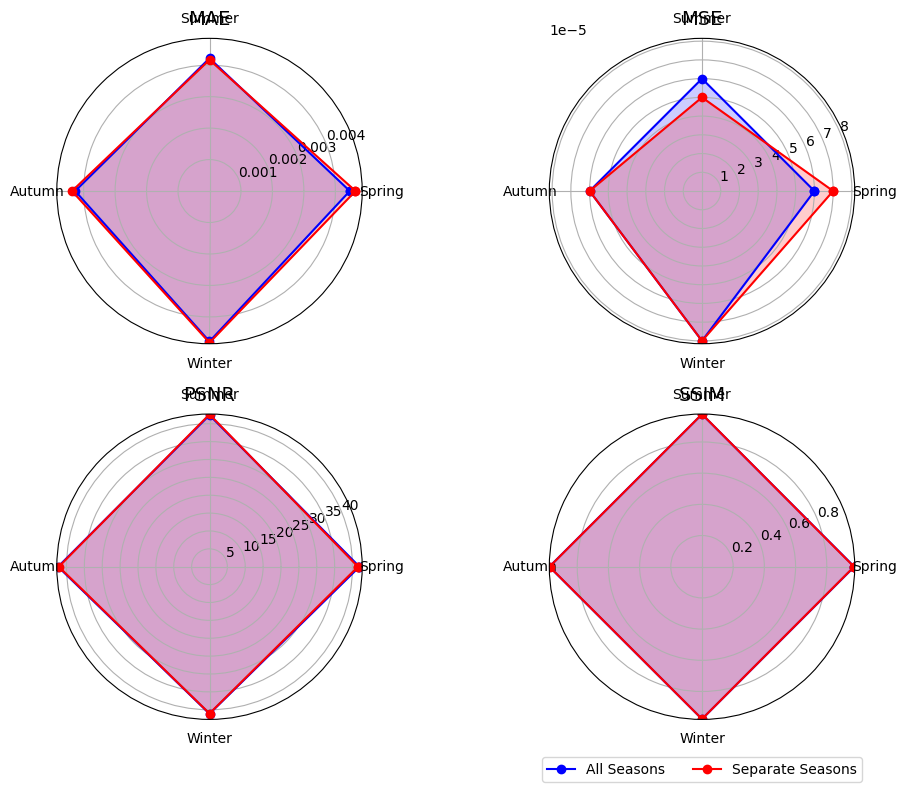

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
season_all_mae = [0.00446, 0.00422, 0.00427, 0.00478]
season_all_mse = [0.00006, 0.00006, 0.00006, 0.00008]
season_all_psnr = [41.9422, 42.4040, 42.3591, 41.1426]
season_all_ssim = [0.9765, 0.9778, 0.9788, 0.9770]

season_sep_mae = [0.00464, 0.00417, 0.00437, 0.00482]
season_sep_mse = [0.00007, 0.00005, 0.00006, 0.00008]
season_sep_psnr = [41.5380, 42.6294, 42.1571, 41.0601]
season_sep_ssim = [0.9747, 0.9784, 0.9778, 0.9765]

metrics = {
    'MAE': (season_all_mae, season_sep_mae),
    'MSE': (season_all_mse, season_sep_mse),
    'PSNR': (season_all_psnr, season_sep_psnr),
    'SSIM': (season_all_ssim, season_sep_ssim)
}

# Radar setup
labels = np.array(seasons)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  # close the loop

fig, axs = plt.subplots(2, 2, subplot_kw={'polar': True}, figsize=(10, 8))
axs = axs.flatten()

for ax, (metric, (all_data, sep_data)) in zip(axs, metrics.items()):
    # Close the loop by repeating the first value
    all_data = np.concatenate((all_data, [all_data[0]]))
    sep_data = np.concatenate((sep_data, [sep_data[0]]))

    ax.plot(angles, all_data, 'o-', label='All Seasons', color='blue')
    ax.fill(angles, all_data, alpha=0.2, color='blue')

    ax.plot(angles, sep_data, 'o-', label='Separate Seasons', color='red')
    ax.fill(angles, sep_data, alpha=0.2, color='red')

    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_title(metric, size=14, pad=10)
    ax.grid(True)

# Common legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.show()

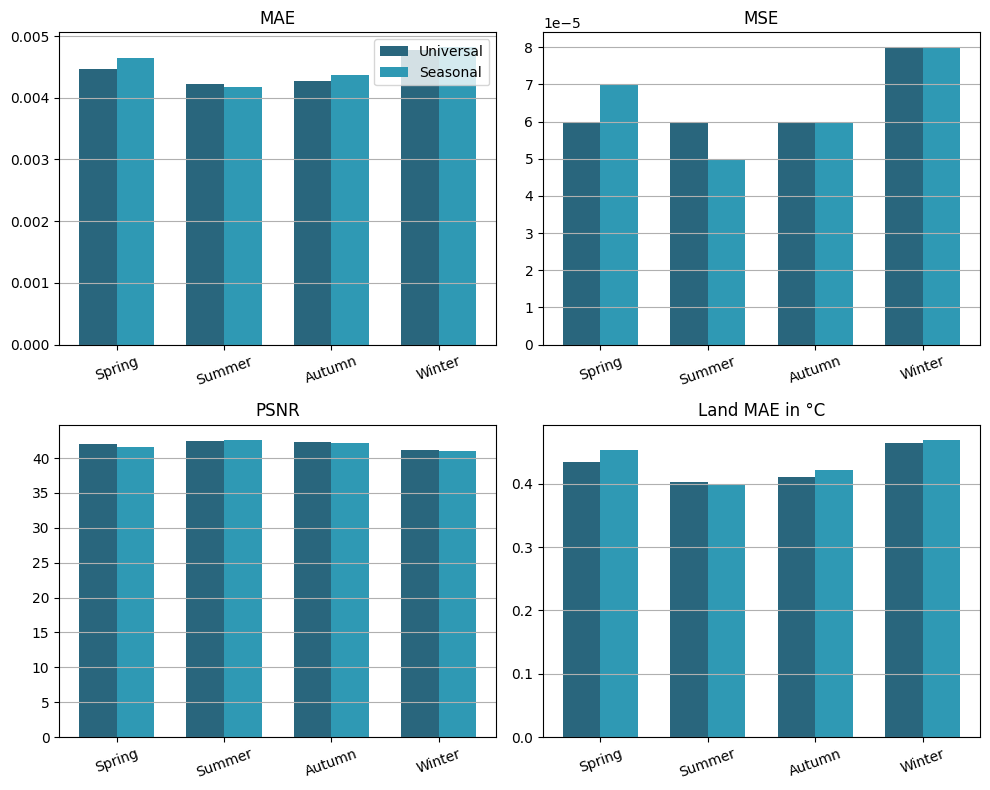

In [11]:
import matplotlib.pyplot as plt
import numpy as np

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
metrics = ['MAE','MSE','PSNR','Land MAE in °C']
all_data = [
    [0.00446,0.00006,41.9422,0.43484],
    [0.00422,0.00006,42.4040,0.40343],
    [0.00427,0.00006,42.3591,0.41139],
    [0.00478,0.00008,41.1426,0.46392]
]
sep_data = [
    [0.00464,0.00007,41.5380,0.45378],
    [0.00417,0.00005,42.6294,0.39857],
    [0.00437,0.00006,42.1571,0.42152],
    [0.00482,0.00008,41.0601,0.46974]
]

all_data = np.array(all_data)
sep_data = np.array(sep_data)

fig, axs = plt.subplots(2,2,figsize=(10,8))
axs = axs.flatten()

x = np.arange(len(seasons))
width = 0.35

for i, metric in enumerate(metrics):
    axs[i].bar(x - width/2, all_data[:,i], width, label='Universal', color='#29667D')
    axs[i].bar(x + width/2, sep_data[:,i], width, label='Seasonal', color='#2F99B4')
    axs[i].set_title(metric)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(seasons, rotation=20)
    axs[i].grid(axis='y')

axs[0].legend()
plt.tight_layout()
plt.show()


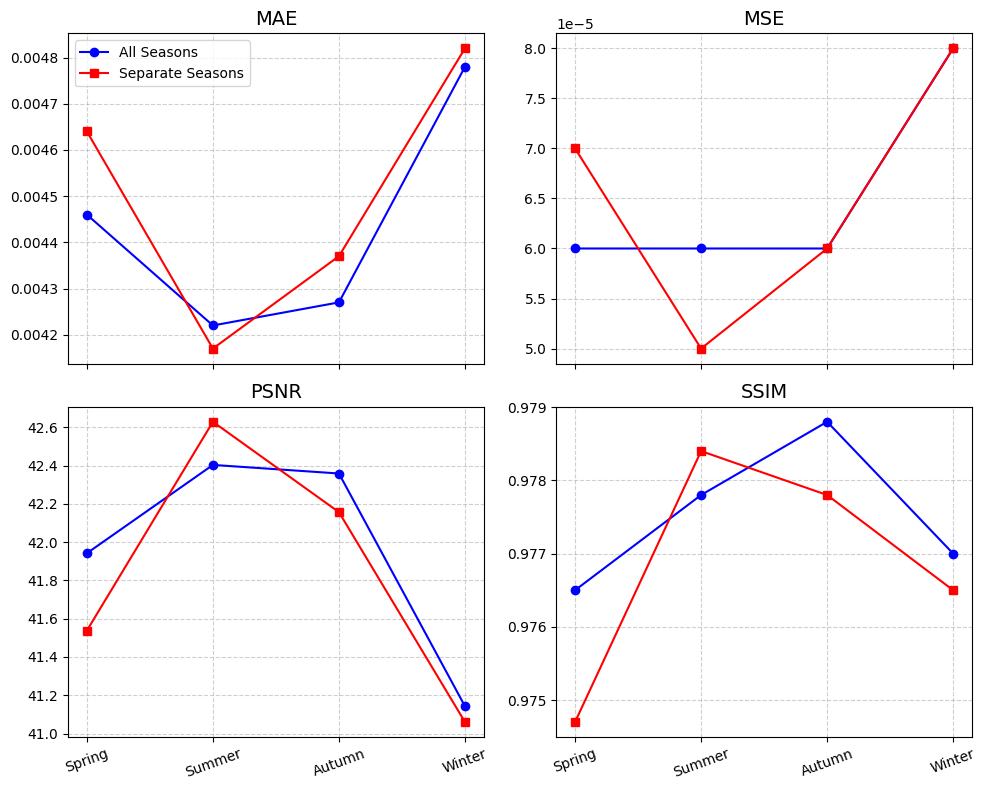

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Data
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
x = np.arange(len(seasons))  # positions for the x-axis

season_all_mae = [0.00446, 0.00422, 0.00427, 0.00478]
season_all_mse = [0.00006, 0.00006, 0.00006, 0.00008]
season_all_psnr = [41.9422, 42.4040, 42.3591, 41.1426]
season_all_ssim = [0.9765, 0.9778, 0.9788, 0.9770]

season_sep_mae = [0.00464, 0.00417, 0.00437, 0.00482]
season_sep_mse = [0.00007, 0.00005, 0.00006, 0.00008]
season_sep_psnr = [41.5380, 42.6294, 42.1571, 41.0601]
season_sep_ssim = [0.9747, 0.9784, 0.9778, 0.9765]

metrics = {
    'MAE': (season_all_mae, season_sep_mae),
    'MSE': (season_all_mse, season_sep_mse),
    'PSNR': (season_all_psnr, season_sep_psnr),
    'SSIM': (season_all_ssim, season_sep_ssim)
}

# Plot
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axs = axs.flatten()

for ax, (metric, (all_data, sep_data)) in zip(axs, metrics.items()):
    ax.plot(x, all_data, marker='o', color='blue', label='All Seasons')
    ax.plot(x, sep_data, marker='s', color='red', label='Separate Seasons')
    ax.set_title(metric, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=20)
    ax.grid(True, linestyle='--', alpha=0.6)

axs[0].legend()
plt.tight_layout()
plt.show()
